# **Data Validation: All Parameters:**

--------

**1. Initial Setup and Data Loading:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
# visualization style: 

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# The dataset: 
df = pd.read_csv('sampled_maternal_data_20k.csv')
print(f"Shape: {df.shape}")

Shape: (20000, 32)


In [5]:
df.columns

Index(['age', 'residence', 'province', 'ethnicity',
       'caste_discrimination_exposure', 'education_level', 'occupation',
       'family_type', 'wealth_index', 'monthly_household_income',
       'food_security', 'housing_quality', 'financial_stress_level', 'parity',
       'anc_visits', 'delivery_type', 'birth_complications',
       'baby_health_status', 'gestational_age', 'maternal_age_at_first_birth',
       'previous_pregnancy_loss', 'partner_support_score',
       'family_support_score', 'domestic_violence_exposure',
       'social_isolation_score', 'sleep_quality', 'stressful_life_events',
       'mental_health_awareness', 'distance_to_health_facility',
       'health_insurance', 'previous_mental_health_consultation',
       'ppd_risk_level'],
      dtype='object')

**2. Basic Data Overview:**

In [6]:
# Display first 10 rows from the dataset: 

df.head(10)

,age,residence,province,ethnicity,caste_discrimination_exposure,education_level,occupation,family_type,wealth_index,monthly_household_income,...,family_support_score,domestic_violence_exposure,social_isolation_score,sleep_quality,stressful_life_events,mental_health_awareness,distance_to_health_facility,health_insurance,previous_mental_health_consultation,ppd_risk_level
0,21,Urban,Koshi,Hill High Caste,No,Secondary,Sales/Service,Nuclear,Richer,51044,...,2.8,Rarely,3.5,7.3,0,Medium,1.13,Yes,Yes,No/Minimal Risk
1,38,Rural,Madhesh,Dalit,Yes,Primary,Manual,Nuclear,Richer,39767,...,4.0,Often,7.4,4.3,3,Low,4.83,No,No,Probable Depression
2,38,Rural,Sudurpashchim,Terai Caste,No,Secondary,Sales/Service,Nuclear,Middle,45000,...,7.5,Never,6.4,6.9,0,High,29.09,No,No,No/Minimal Risk
3,41,Rural,Sudurpashchim,Janajati,No,Secondary,Professional/Technical/Managerial,Joint/Extended,Poorer,17768,...,6.2,Never,2.0,5.7,0,Medium,5.47,No,No,No/Minimal Risk
4,43,Rural,Gandaki,Janajati,No,Primary,Agriculture,Nuclear,Richer,61897,...,6.6,Never,6.6,5.4,2,Medium,2.18,No,No,Possible Depression
5,20,Urban,Madhesh,Terai Caste,No,Higher,Agriculture,Nuclear,Richer,53230,...,6.1,Never,8.1,5.4,1,High,0.85,No,No,Possible Depression
6,36,Rural,Madhesh,Muslim,No,Secondary,Clerical,Joint/Extended,Poorer,15000,...,10.0,Never,3.8,6.7,1,Medium,6.50,No,No,Possible Depression
7,40,Rural,Koshi,Terai Caste,No,No education,Manual,Joint/Extended,Richest,108560,...,6.0,Never,1.7,9.7,1,Medium,1.65,No,No,No/Minimal Risk
8,34,Rural,Lumbini,Dalit,No,No education,Manual,Nuclear,Richest,142719,...,7.3,Sometimes,3.0,5.9,1,Low,2.07,No,No,Possible Depression
9,43,Rural,Bagmati,Dalit,No,No education,Agriculture,Nuclear,Poorer,23695,...,4.3,Never,5.5,9.1,0,Low,3.45,No,No,Possible Depression


In [10]:
# 4 random data samples from the dataset: 

df.sample(n= 4)

,age,residence,province,ethnicity,caste_discrimination_exposure,education_level,occupation,family_type,wealth_index,monthly_household_income,...,family_support_score,domestic_violence_exposure,social_isolation_score,sleep_quality,stressful_life_events,mental_health_awareness,distance_to_health_facility,health_insurance,previous_mental_health_consultation,ppd_risk_level
17895,44,Rural,Lumbini,Dalit,Yes,Primary,Agriculture,Nuclear,Richer,51505,...,6.9,Sometimes,7.7,6.6,1,Low,1.43,No,No,Possible Depression
18151,20,Rural,Sudurpashchim,Hill High Caste,No,Secondary,Agriculture,Nuclear,Richer,74268,...,7.9,Never,6.8,3.9,0,High,24.41,No,No,Possible Depression
10736,24,Rural,Karnali,Muslim,No,Secondary,Agriculture,Nuclear,Poorest,12826,...,4.0,Never,3.0,8.3,0,Medium,16.82,No,Yes,Possible Depression
6503,18,Rural,Sudurpashchim,Hill High Caste,No,Secondary,Sales/Service,Nuclear,Middle,37646,...,8.3,Never,5.7,8.1,0,Medium,13.11,No,No,No/Minimal Risk


In [11]:
# Data types and memory usage:
print("=" * 30)
print("DATA TYPES AND MEMORY USAGE:")
print("=" * 30)
(df.info())

DATA TYPES AND MEMORY USAGE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  20000 non-null  int64  
 1   residence                            20000 non-null  object 
 2   province                             20000 non-null  object 
 3   ethnicity                            20000 non-null  object 
 4   caste_discrimination_exposure        20000 non-null  object 
 5   education_level                      20000 non-null  object 
 6   occupation                           20000 non-null  object 
 7   family_type                          20000 non-null  object 
 8   wealth_index                         20000 non-null  object 
 9   monthly_household_income             20000 non-null  int64  
 10  food_security                        20000 non-null  object 
 11 

In [12]:
# Basic statistical summary for numerical columns: 
print("=" * 40)
print("STATISTICAL SUMMARY - NUMERICAL COLUMNS:")
print("=" * 40)
df.describe()

STATISTICAL SUMMARY - NUMERICAL COLUMNS:


,age,monthly_household_income,housing_quality,financial_stress_level,parity,anc_visits,gestational_age,maternal_age_at_first_birth,partner_support_score,family_support_score,social_isolation_score,sleep_quality,stressful_life_events,distance_to_health_facility
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,29.975450,45830.999300,5.582200,5.01695,1.630050,5.497250,38.489000,21.566200,6.593150,6.209595,4.569215,6.659985,1.083450,4.606329
std,8.348696,39026.142782,2.042878,2.95508,1.461093,2.422042,2.265598,4.697619,2.115375,2.220976,2.130144,1.691710,1.074916,5.815983
min,16.000000,8000.000000,1.000000,0.00000,0.000000,0.000000,29.000000,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000
25%,23.000000,18000.000000,4.000000,3.00000,0.000000,4.000000,37.000000,19.000000,5.100000,4.600000,3.000000,5.500000,0.000000,1.200000
50%,30.000000,31644.500000,6.000000,5.00000,1.000000,6.000000,39.000000,21.000000,6.700000,6.200000,4.400000,6.700000,1.000000,2.620000
75%,37.000000,59835.250000,7.000000,7.00000,2.000000,7.000000,40.000000,23.000000,8.200000,7.800000,6.000000,7.900000,2.000000,5.630000
max,44.000000,180000.000000,10.000000,10.00000,8.000000,12.000000,42.000000,44.000000,10.000000,10.000000,10.000000,10.000000,5.000000,50.000000


**3. Missing Values Analysis:**

In [13]:
# Check missing values: 

print("=" * 30)
print("MISSING VALUES ANALYSIS:")
print("=" * 30)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
)

if len(missing_data) == 0:
    print("NO MISSING VALUES DETECTED - Dataset is complete!")
else:
    print(missing_data.to_string(index=False))
    
print(f"Total missing values: {df.isnull().sum().sum()}")

MISSING VALUES ANALYSIS:
NO MISSING VALUES DETECTED - Dataset is complete!
Total missing values: 0


No missing values as expected because the whole dataset was synthetized from scratch using actual data statistics using some of the most trusted data sources for nepal. 

**4. Duplicate Records Check:**

In [14]:
# Check for duplicate rows: 

print("=" * 30)
print("DUPLICATE RECORDS CHECK:")
print("=" * 30)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df)*100):.2f}%")

if duplicates > 0:
    print("\nFirst 5 duplicate rows:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("✓ NO DUPLICATE RECORDS FOUND")

DUPLICATE RECORDS CHECK:
Number of duplicate rows: 0
Percentage of duplicates: 0.00%
✓ NO DUPLICATE RECORDS FOUND


Again, no duplicates as expected.

**5. Target Variable Distribution ($PPD$ Risk Level):**

TARGET VARIABLE: PPD RISK LEVEL DISTRIBUTION:
         Risk Level  Count  Percentage
    No/Minimal Risk   8149       40.74
Possible Depression   8092       40.46
Probable Depression   3759       18.80


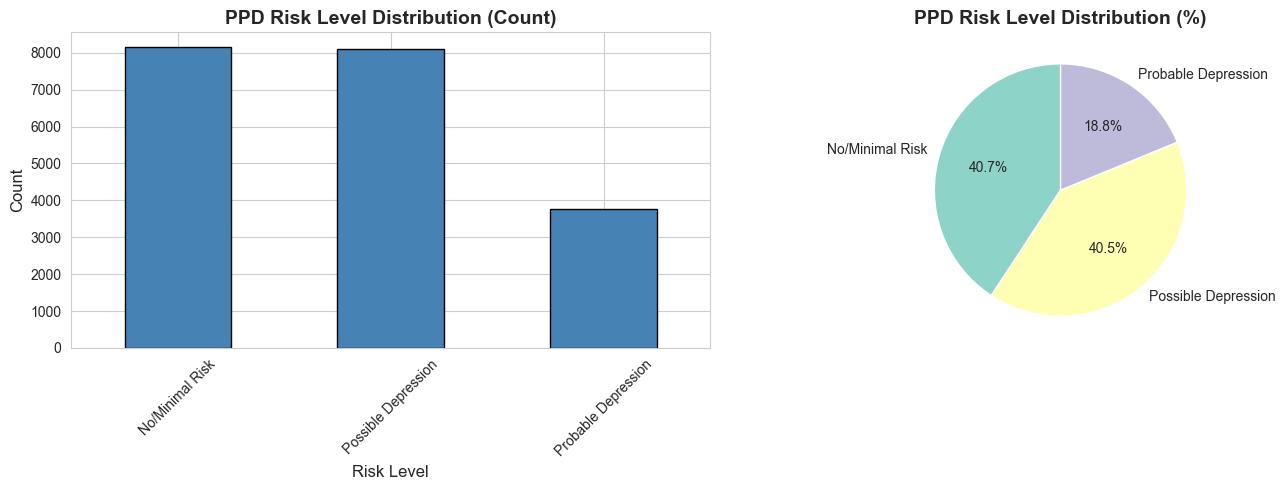

In [15]:
# Analyze PPD risk level distribution:

print("=" * 45)
print("TARGET VARIABLE: PPD RISK LEVEL DISTRIBUTION:")
print("=" * 45)

ppd_dist = df['ppd_risk_level'].value_counts().sort_index()
ppd_pct = (df['ppd_risk_level'].value_counts(normalize=True) * 100).sort_index()

summary_df = pd.DataFrame({
    'Risk Level': ppd_dist.index,
    'Count': ppd_dist.values,
    'Percentage': ppd_pct.values.round(2)
})

print(summary_df.to_string(index=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ppd_dist.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('PPD Risk Level Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Risk Level', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Pie chart
ax2.pie(ppd_dist.values, labels=ppd_dist.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette("Set3"))
ax2.set_title('PPD Risk Level Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Here, target labels class imbalence is observed. This imbalence is expected because the high risk cases are less as compared to low risk cases. We may need to adress this issue using oversampling methods to better generalize the overall performance of the model later. 

**6. Numerical Variables Distribution Analysis:**

In [16]:
# Analyze all numerical columns: 
print("=" * 35)
print("NUMERICAL VARIABLES DISTRIBUTION:")
print("=" * 35)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    print(f"\n{col.upper()}")
    print("-" * 30)
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std Dev: {df[col].std():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")
    print(f"Skewness: {df[col].skew():.3f}")
    print(f"Kurtosis: {df[col].kurtosis():.3f}")

NUMERICAL VARIABLES DISTRIBUTION:

AGE
------------------------------
Mean: 29.98
Median: 30.00
Std Dev: 8.35
Min: 16.00
Max: 44.00
Skewness: 0.003
Kurtosis: -1.203

MONTHLY_HOUSEHOLD_INCOME
------------------------------
Mean: 45831.00
Median: 31644.50
Std Dev: 39026.14
Min: 8000.00
Max: 180000.00
Skewness: 1.518
Kurtosis: 1.536

HOUSING_QUALITY
------------------------------
Mean: 5.58
Median: 6.00
Std Dev: 2.04
Min: 1.00
Max: 10.00
Skewness: 0.024
Kurtosis: -0.839

FINANCIAL_STRESS_LEVEL
------------------------------
Mean: 5.02
Median: 5.00
Std Dev: 2.96
Min: 0.00
Max: 10.00
Skewness: -0.085
Kurtosis: -1.026

PARITY
------------------------------
Mean: 1.63
Median: 1.00
Std Dev: 1.46
Min: 0.00
Max: 8.00
Skewness: 0.922
Kurtosis: 0.679

ANC_VISITS
------------------------------
Mean: 5.50
Median: 6.00
Std Dev: 2.42
Min: 0.00
Max: 12.00
Skewness: -0.022
Kurtosis: -0.244

GESTATIONAL_AGE
------------------------------
Mean: 38.49
Median: 39.00
Std Dev: 2.27
Min: 29.00
Max: 42.00
Skewn

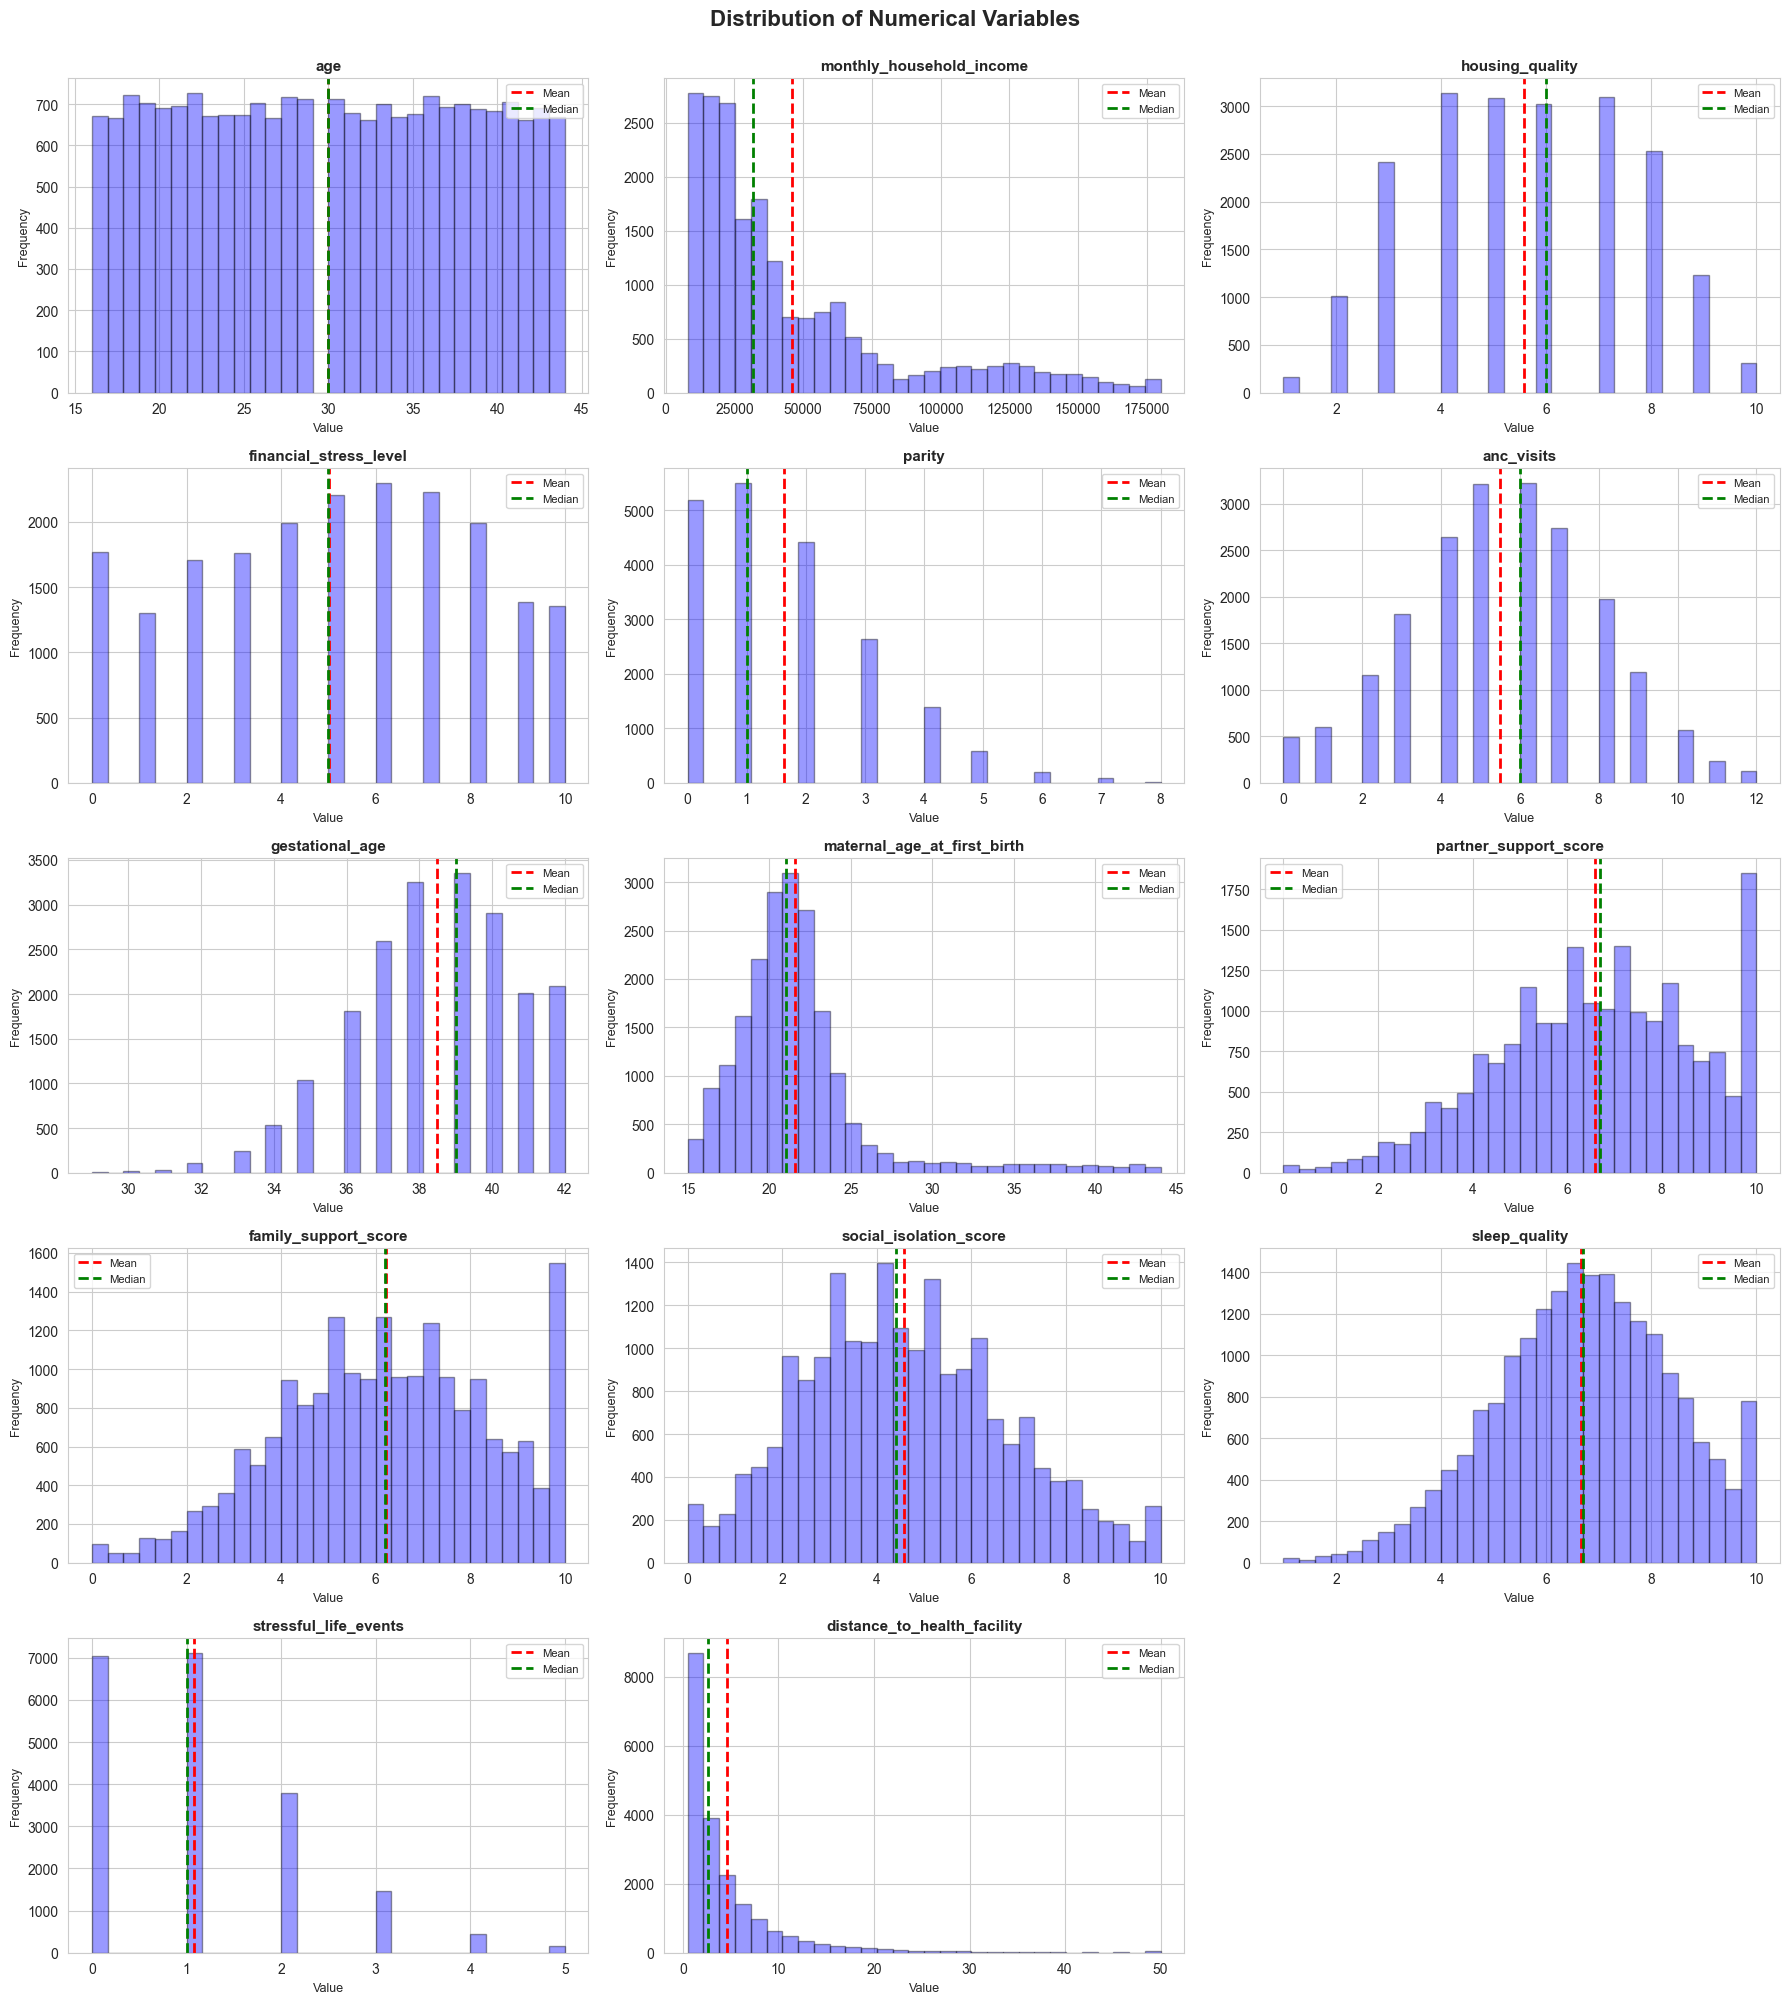

In [17]:
# Visualize numerical distributions: 

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    df[col].hist(bins=30, ax=ax, color='blue', edgecolor='black', alpha=0.4)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label='Median')
    ax.legend(fontsize=8)

# Hide extra subplots
for idx in range(n_cols, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**7. Categorical Variables Analysis:**

In [18]:
# Analyze categorical variables
print("=" * 35)
print("CATEGORICAL VARIABLES DISTRIBUTION:")
print("=" * 35)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print("-" * 30)
    value_counts = df[col].value_counts()
    value_pcts = (df[col].value_counts(normalize=True) * 100).round(2)
    
    summary = pd.DataFrame({
        'Category': value_counts.index,
        'Count': value_counts.values,
        'Percentage': value_pcts.values
    })
    
    print(summary.to_string(index=False))
    print(f"Unique values: {df[col].nunique()}")

CATEGORICAL VARIABLES DISTRIBUTION:

RESIDENCE:
------------------------------
Category  Count  Percentage
   Rural  12591       62.96
   Urban   7409       37.04
Unique values: 2

PROVINCE:
------------------------------
     Category  Count  Percentage
      Bagmati   3567       17.84
        Koshi   3200       16.00
      Lumbini   3022       15.11
      Madhesh   2947       14.74
      Karnali   2463       12.32
Sudurpashchim   2444       12.22
      Gandaki   2357       11.78
Unique values: 7

ETHNICITY:
------------------------------
       Category  Count  Percentage
Hill High Caste   7534       37.67
          Dalit   4304       21.52
       Janajati   3688       18.44
    Terai Caste   3503       17.52
         Muslim    971        4.86
Unique values: 5

CASTE_DISCRIMINATION_EXPOSURE:
------------------------------
Category  Count  Percentage
      No  17615       88.08
     Yes   2385       11.92
Unique values: 2

EDUCATION_LEVEL:
------------------------------
    Category  

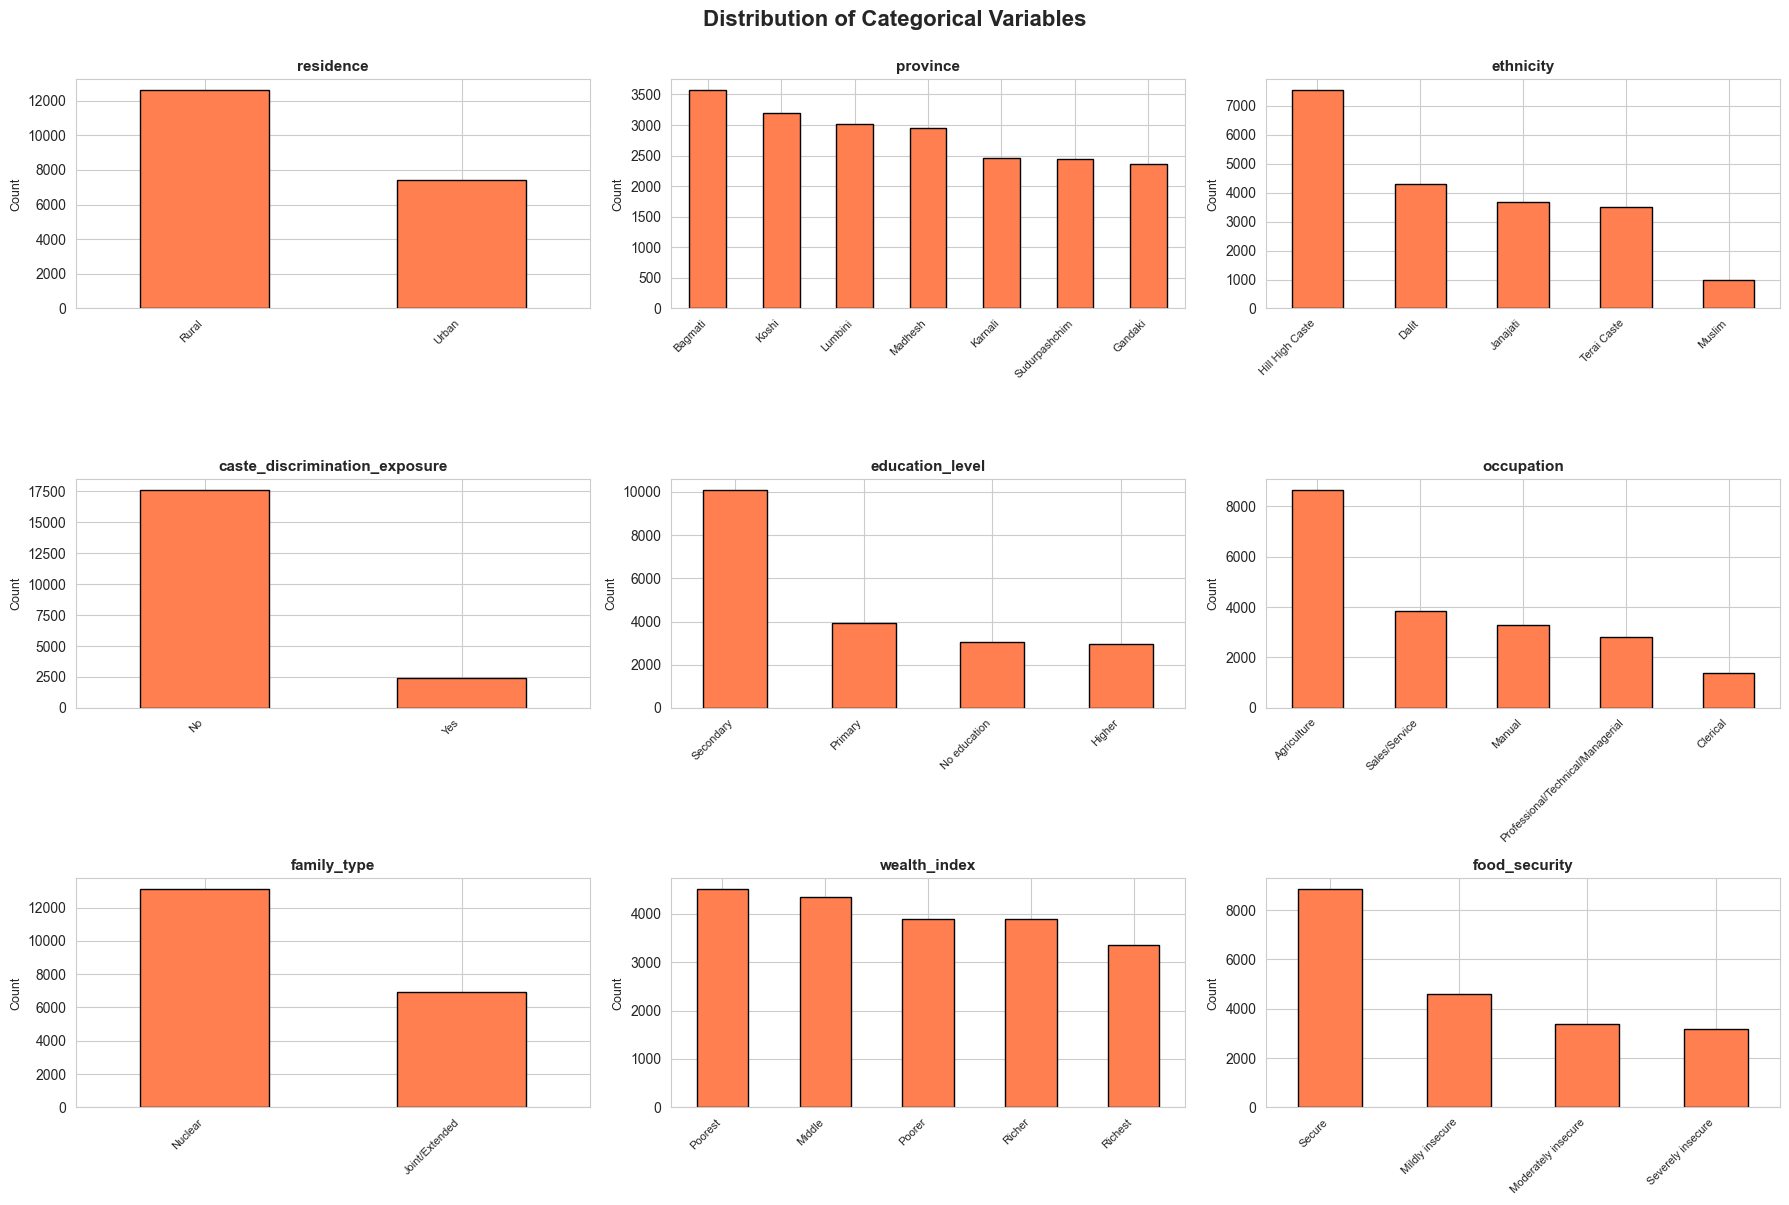

In [19]:
# Visualize key categorical variables (top 10)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
key_cats = [col for col in categorical_cols if col != 'ppd_risk_level'][:9]

if len(key_cats) > 0:
    n_rows = (len(key_cats) + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
    axes = axes.flatten() if len(key_cats) > 1 else [axes]

    for idx, col in enumerate(key_cats):
        ax = axes[idx]
        value_counts = df[col].value_counts()
        
        if len(value_counts) <= 10:
            value_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        else:
            value_counts.head(10).plot(kind='bar', ax=ax, color='coral', edgecolor='black')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
            ax.set_title(f'{col} (Top 10)', fontsize=11, fontweight='bold')
            
        ax.set_title(f'{col}', fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Count', fontsize=9)

    # Hide extra subplots
    for idx in range(len(key_cats), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

**8. Age Distribution Analysis:**

AGE DISTRIBUTION ANALYSIS:
Mean Age: 29.98
Median Age: 30.00
Std Dev: 8.35
Min Age: 16.00
Max Age: 44.00
Age Range: 28.00

Age Group Distribution:
age_group
<20      3452
20-24    3440
25-29    3511
30-34    3386
35-39    3486
40+      2725
Name: count, dtype: int64


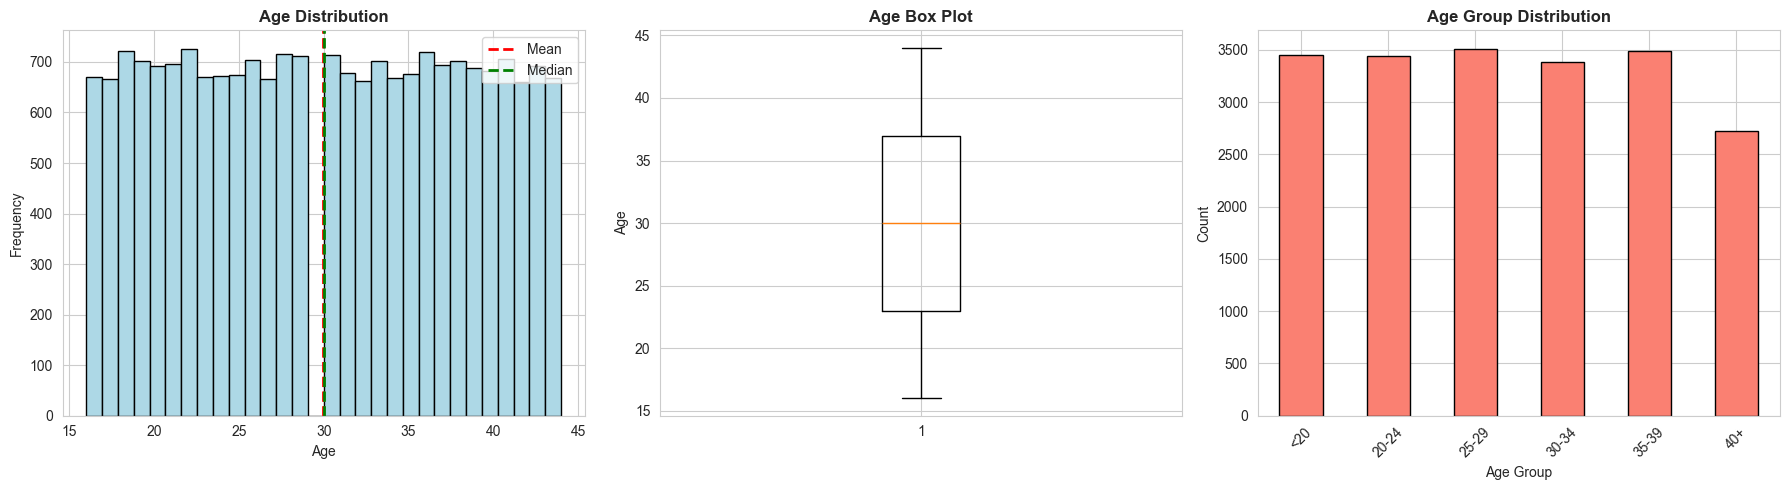

In [20]:
# Detailed age analysis: 

print("=" * 25)
print("AGE DISTRIBUTION ANALYSIS:")
print("=" * 25)

age_stats = {
    'Mean Age': df['age'].mean(),
    'Median Age': df['age'].median(),
    'Std Dev': df['age'].std(),
    'Min Age': df['age'].min(),
    'Max Age': df['age'].max(),
    'Age Range': df['age'].max() - df['age'].min()
}

for key, value in age_stats.items():
    print(f"{key}: {value:.2f}")

# Age groups
df_temp = df.copy()
df_temp['age_group'] = pd.cut(df_temp['age'], 
                               bins=[0, 20, 25, 30, 35, 40, 100],
                               labels=['<20', '20-24', '25-29', '30-34', '35-39', '40+'])

print("\nAge Group Distribution:")
print(df_temp['age_group'].value_counts().sort_index())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['age'], bins=30, color='lightblue', edgecolor='black')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()

# Box plot
axes[1].boxplot(df['age'], vert=True)
axes[1].set_title('Age Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Age', fontsize=10)

# Age groups
df_temp['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[2], 
                                                        color='salmon', edgecolor='black')
axes[2].set_title('Age Group Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age Group', fontsize=10)
axes[2].set_ylabel('Count', fontsize=10)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**9. Outlier Detection:**

In [21]:
# Detect outliers using IQR method
print("=" * 30)
print("OUTLIER DETECTION (IQR METHOD):")
print("=" * 30)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        'Variable': col,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

OUTLIER DETECTION (IQR METHOD):
                   Variable  Lower_Bound  Upper_Bound  Outlier_Count  Outlier_Percentage
                        age        2.000       58.000              0                0.00
   monthly_household_income   -44752.875   122588.125           1588                7.94
            housing_quality       -0.500       11.500              0                0.00
     financial_stress_level       -3.000       13.000              0                0.00
                     parity       -3.000        5.000            288                1.44
                 anc_visits       -0.500       11.500            122                0.61
            gestational_age       32.500       44.500            167                0.83
maternal_age_at_first_birth       13.000       29.000           1213                6.07
      partner_support_score        0.450       12.850             55                0.27
       family_support_score       -0.200       12.600              0          

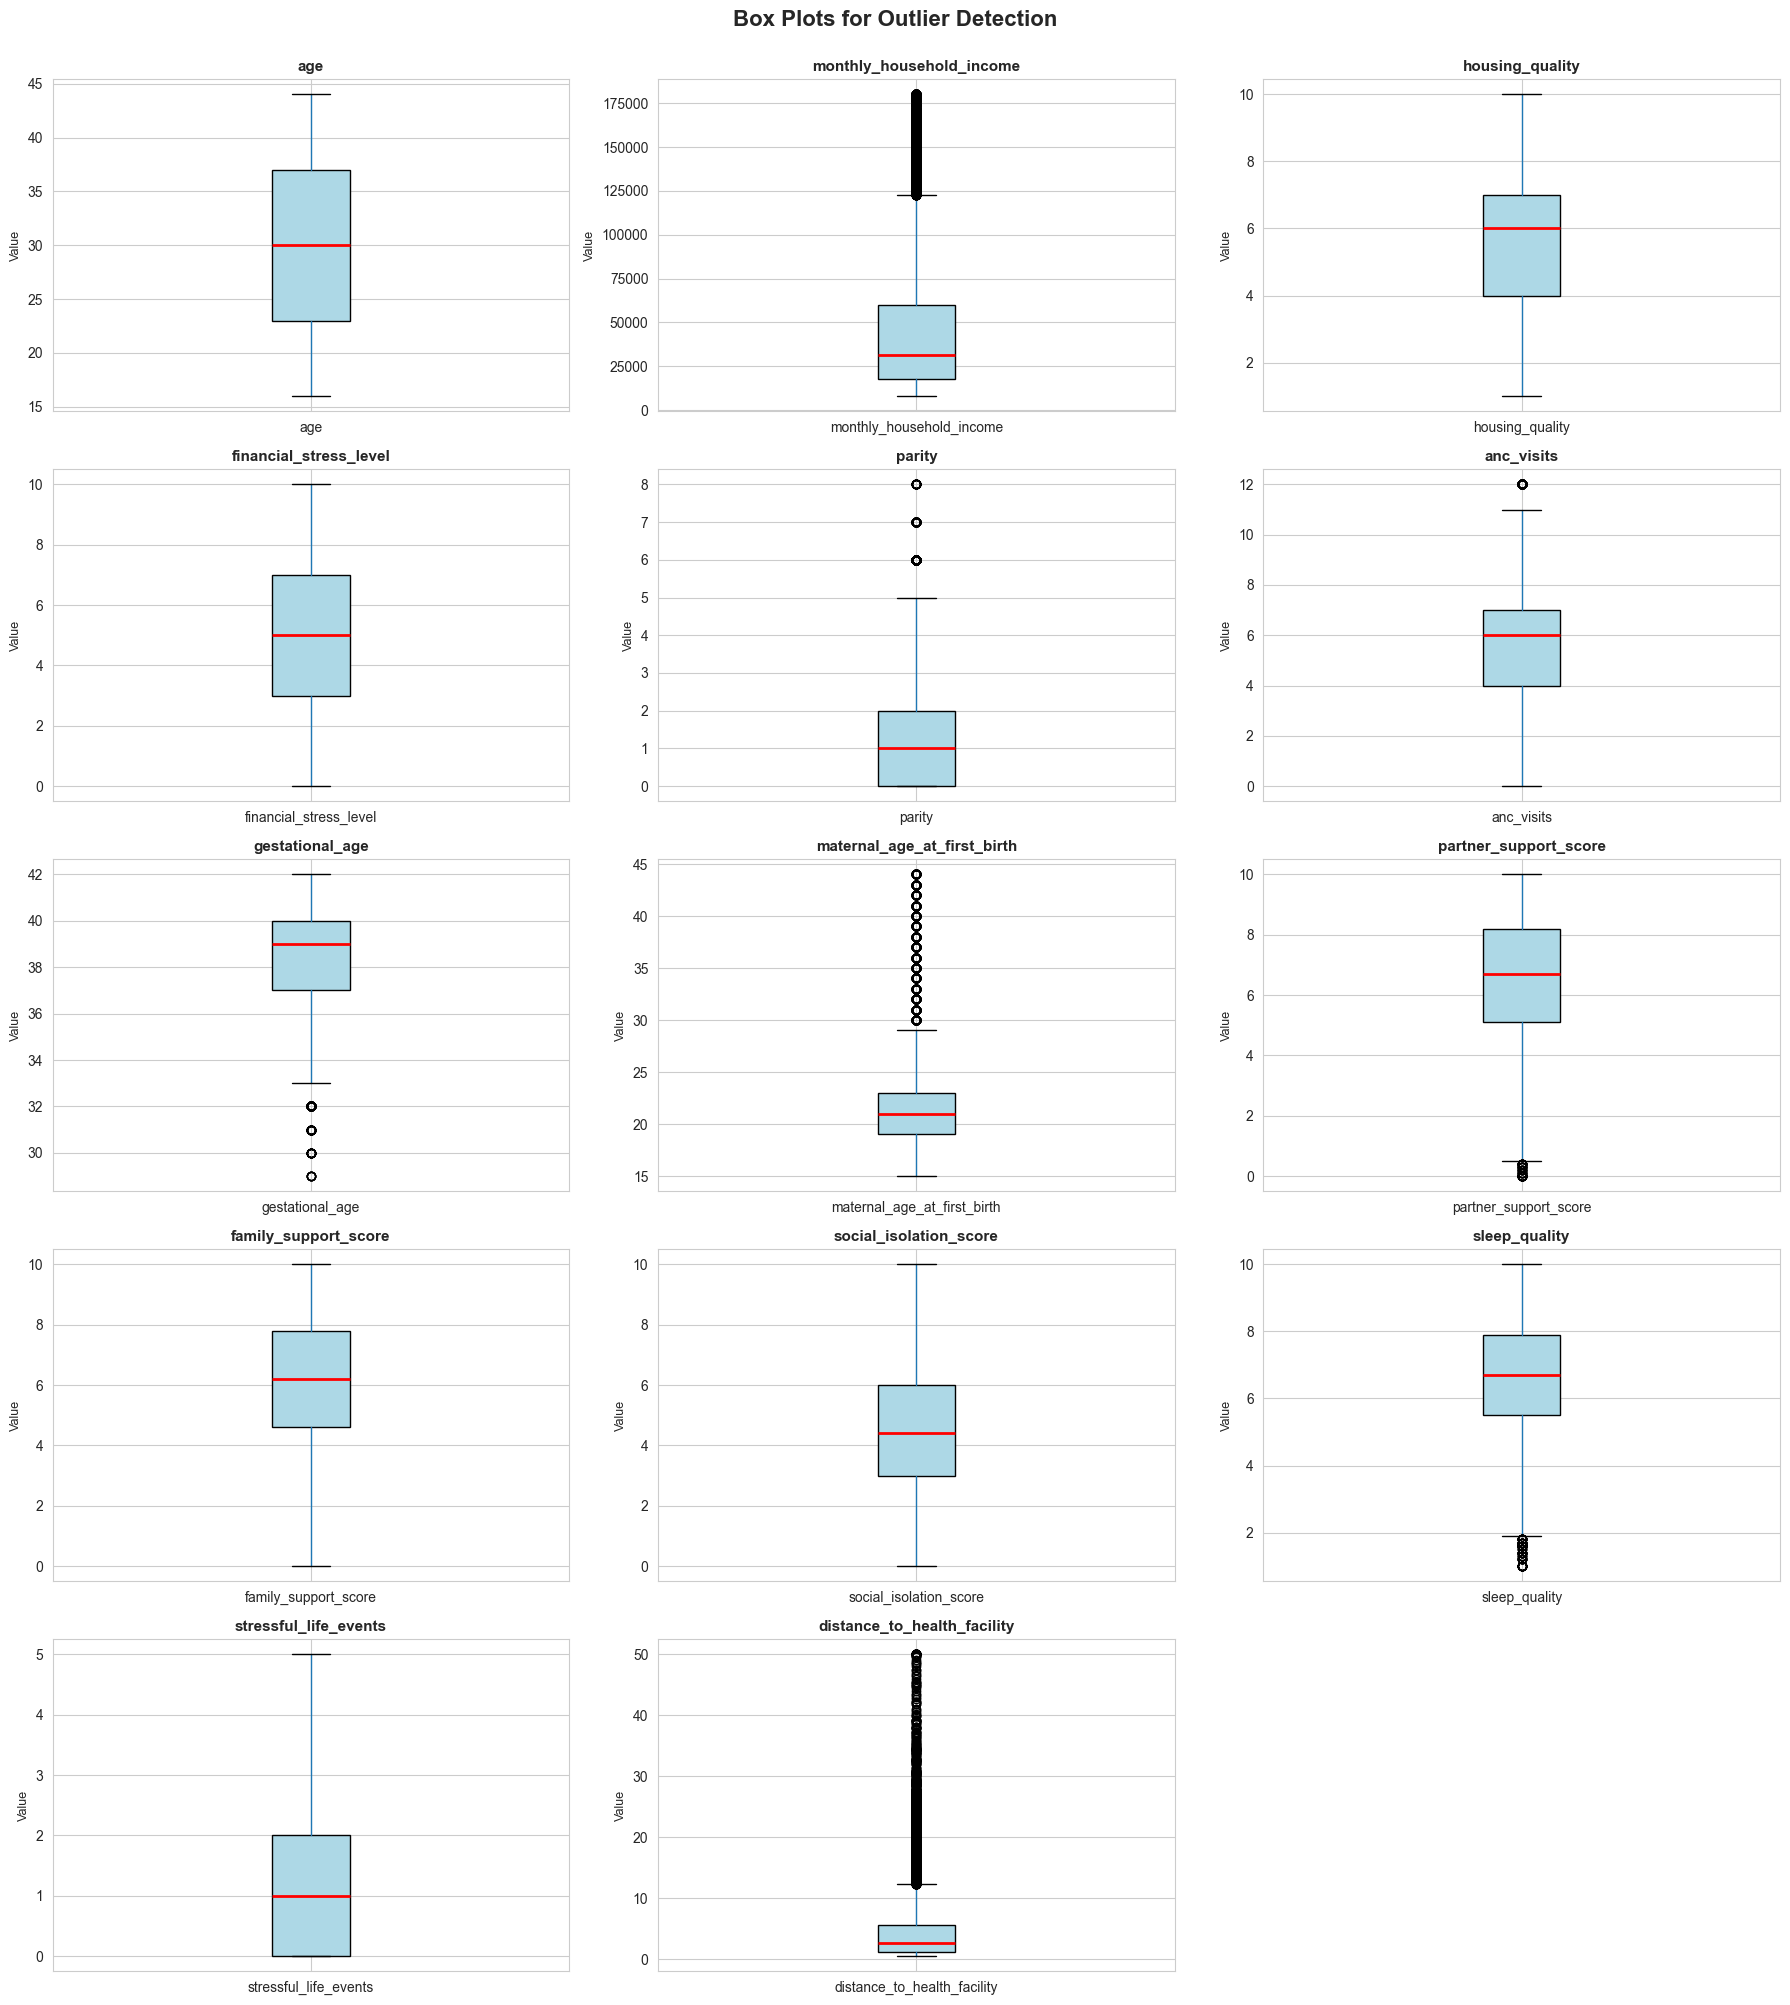

In [22]:
# Box plots for outlier visualization:

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    df.boxplot(column=col, ax=ax, patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)

# Hide extra subplots
for idx in range(n_cols, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**10. Correlation Analysis:**

In [23]:
# Correlation matrix for numerical variables
print("=" * 20)
print("CORRELATION ANALYSIS:")
print("=" * 20)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(3))

# Find strong correlations (|r| > 0.5)
print("\n" + "=" * 60)
print("STRONG CORRELATIONS (|r| > 0.5)")
print("=" * 60)

strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            strong_corr.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlation': round(correlation_matrix.iloc[i, j], 3)
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    strong_corr_df = strong_corr_df.sort_values('Correlation', ascending=False, key=abs)
    print(strong_corr_df.to_string(index=False))
else:
    print("No strong correlations found (|r| > 0.5)")

CORRELATION ANALYSIS:
Correlation Matrix:
                               age  monthly_household_income  housing_quality  \
age                          1.000                    -0.005           -0.003   
monthly_household_income    -0.005                     1.000            0.736   
housing_quality             -0.003                     0.736            1.000   
financial_stress_level       0.007                    -0.702           -0.696   
parity                       0.432                    -0.118           -0.132   
anc_visits                  -0.023                     0.237            0.290   
gestational_age              0.007                     0.012            0.007   
maternal_age_at_first_birth  0.440                     0.051            0.060   
partner_support_score       -0.018                     0.045            0.041   
family_support_score        -0.001                    -0.058           -0.075   
social_isolation_score       0.010                     0.088       

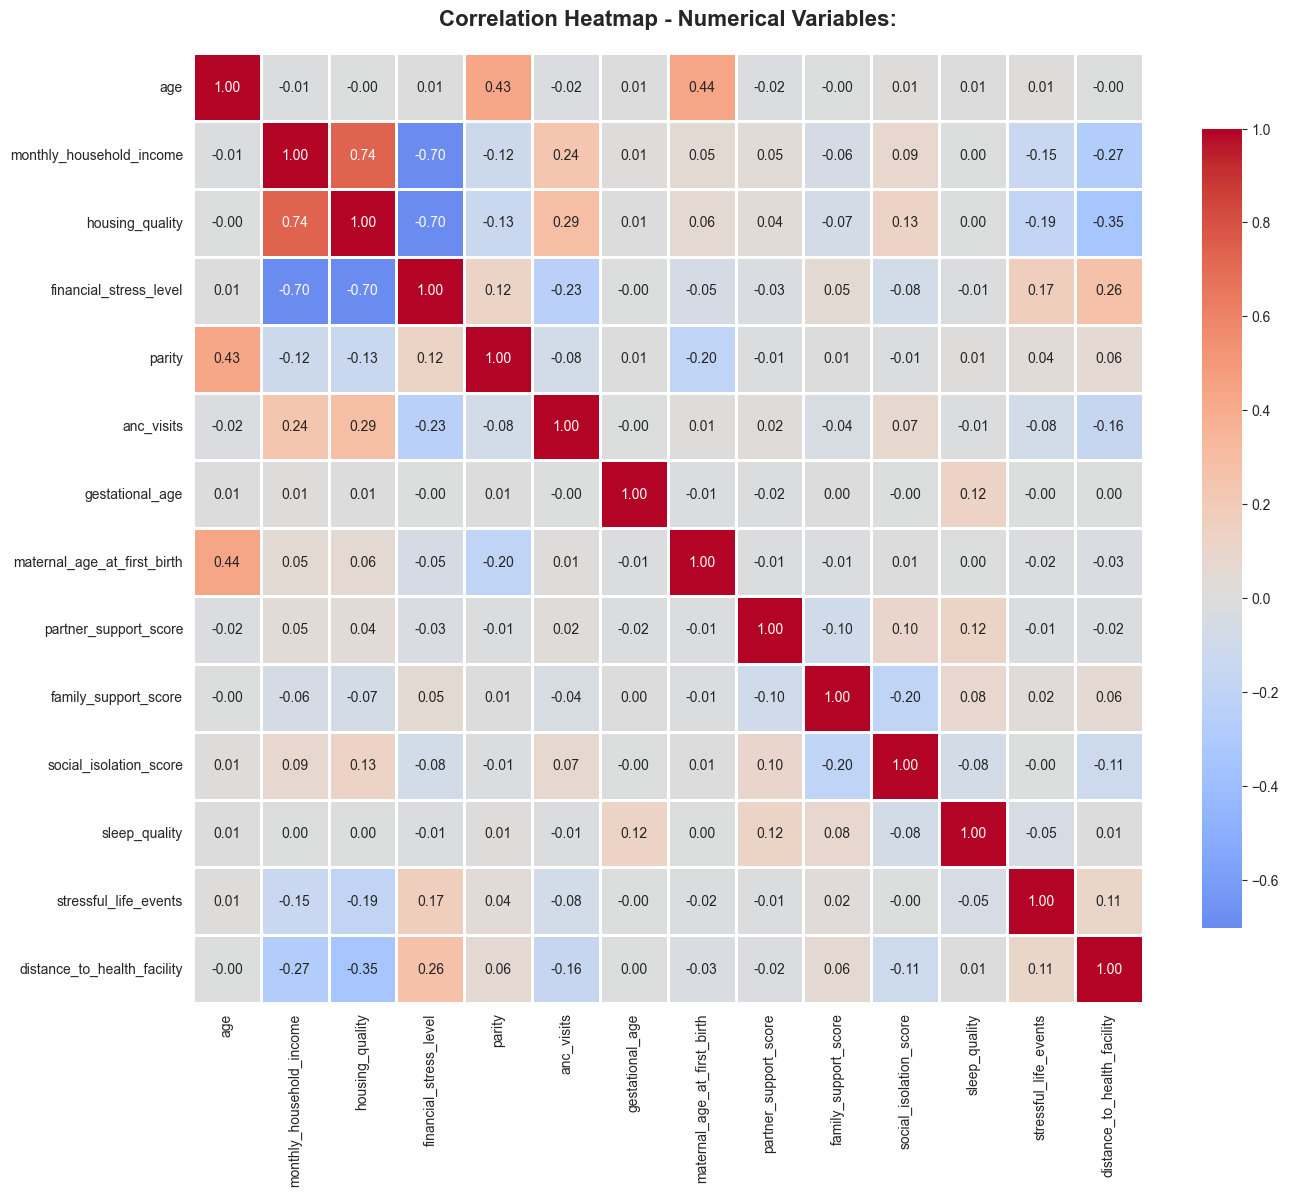

In [24]:
# Correlation heatmap: 

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Variables:', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**11. PPD Risk Level vs Key Variables:**

In [25]:
# PPD risk level by categorical variables
print("=" * 45)
print("PPD RISK LEVEL BY KEY CATEGORICAL VARIABLES:")
print("=" * 45)

key_categorical = ['residence', 'education_level', 'wealth_index', 
                   'family_type', 'domestic_violence_exposure']

for cat_var in key_categorical:
    if cat_var in df.columns:
        print(f"\n{cat_var.upper()}")
        print("-" * 80)
        crosstab = pd.crosstab(df[cat_var], df['ppd_risk_level'], 
                               normalize='index') * 100
        print(crosstab.round(2))

PPD RISK LEVEL BY KEY CATEGORICAL VARIABLES:

RESIDENCE
--------------------------------------------------------------------------------
ppd_risk_level  No/Minimal Risk  Possible Depression  Probable Depression
residence                                                                
Rural                     35.62                42.54                21.84
Urban                     49.45                36.93                13.62

EDUCATION_LEVEL
--------------------------------------------------------------------------------
ppd_risk_level   No/Minimal Risk  Possible Depression  Probable Depression
education_level                                                           
Higher                     45.19                37.25                17.56
No education               35.98                42.81                21.21
Primary                    36.03                43.15                20.82
Secondary                  42.71                39.65                17.65

WEALTH_INDEX
-----

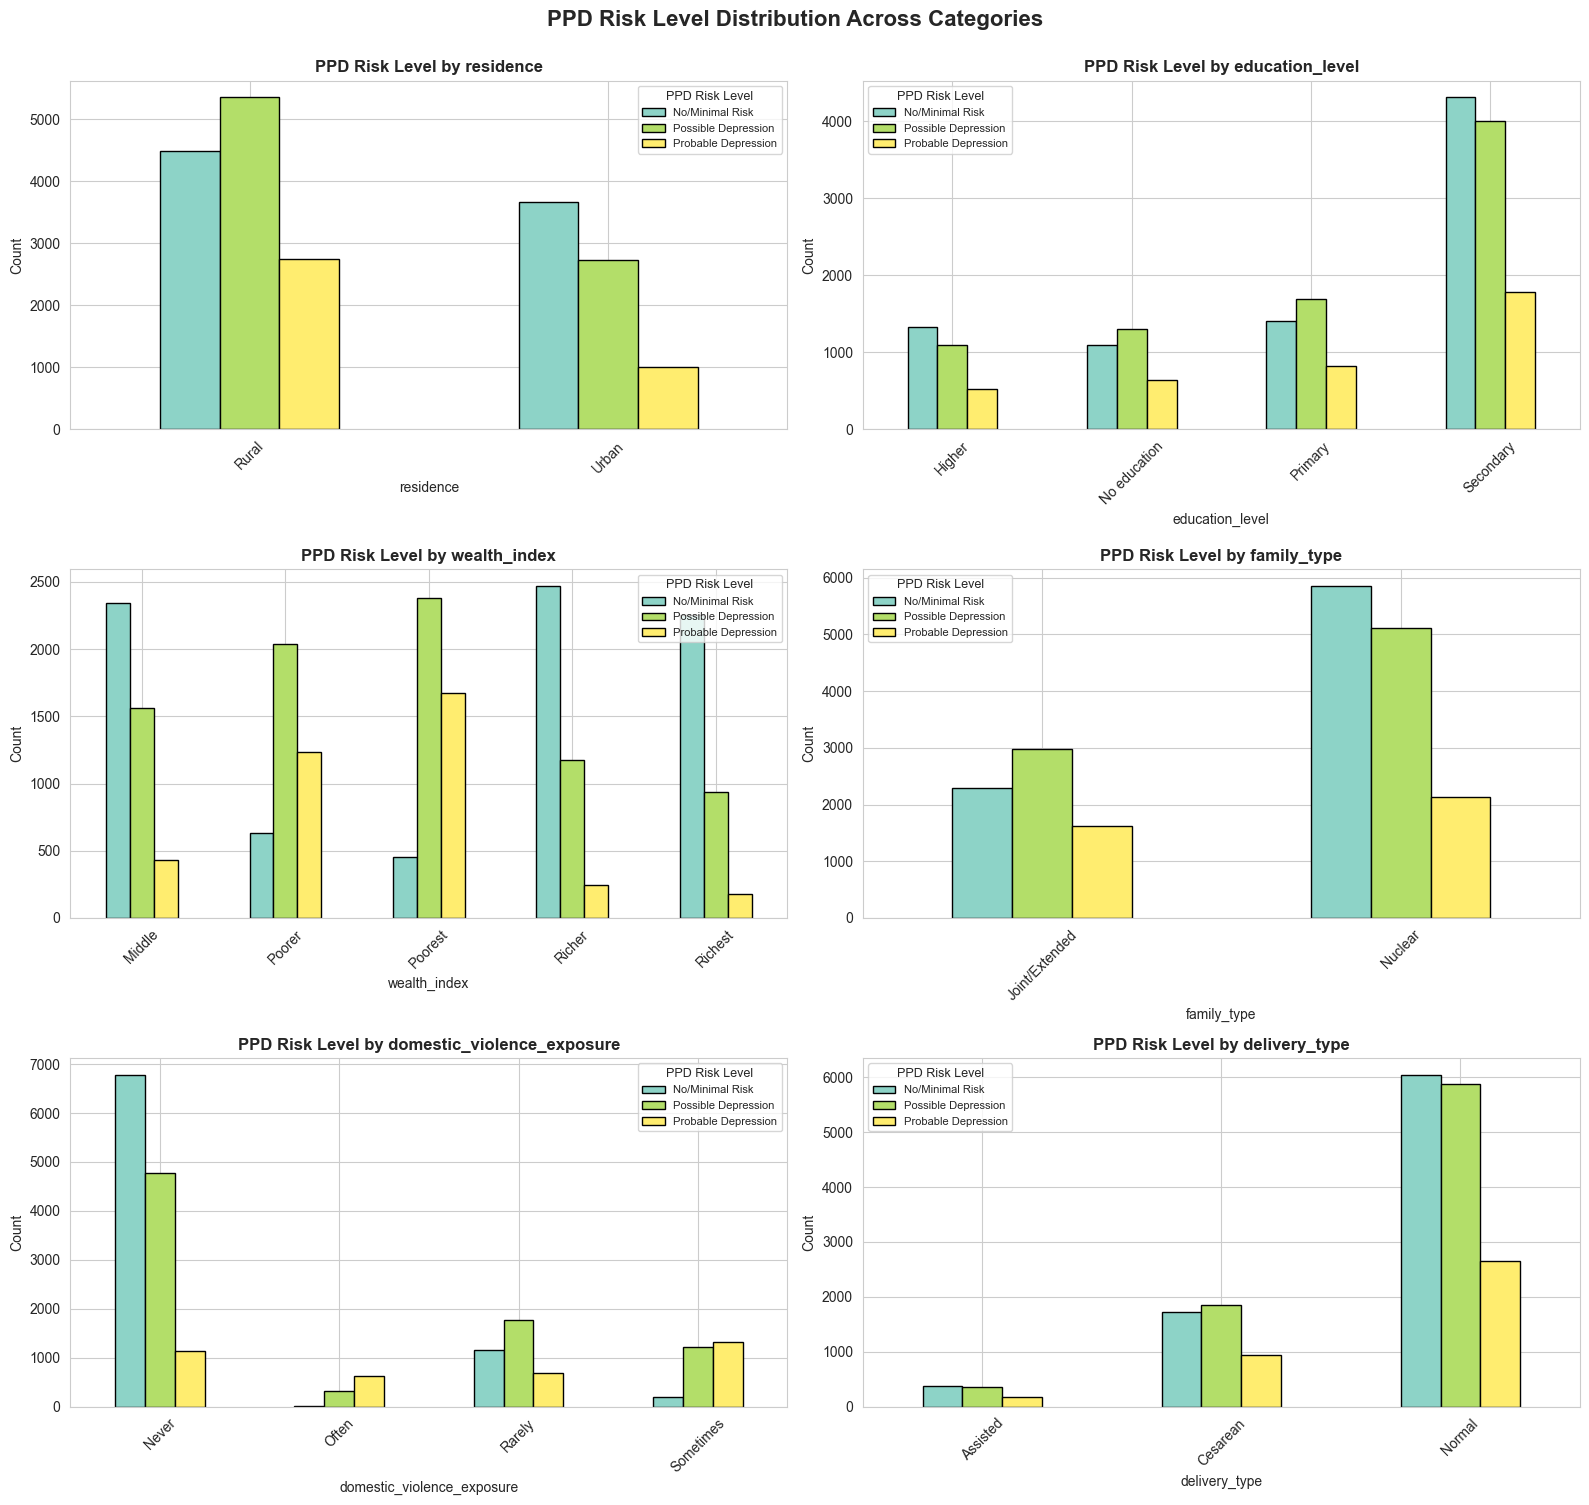

In [26]:
# Visualize PPD risk by key categorical variables
key_categorical = ['residence', 'education_level', 'wealth_index', 
                   'family_type', 'domestic_violence_exposure', 
                   'delivery_type']

available_cats = [col for col in key_categorical if col in df.columns]

if len(available_cats) > 0:
    n_rows = (len(available_cats) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, n_rows*5))
    axes = axes.flatten() if len(available_cats) > 1 else [axes]

    for idx, cat_var in enumerate(available_cats):
        ax = axes[idx]
        crosstab = pd.crosstab(df[cat_var], df['ppd_risk_level'])
        crosstab.plot(kind='bar', ax=ax, stacked=False, colormap='Set3', edgecolor='black')
        ax.set_title(f'PPD Risk Level by {cat_var}', fontsize=12, fontweight='bold')
        ax.set_xlabel(cat_var, fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.legend(title='PPD Risk Level', fontsize=8, title_fontsize=9)
        ax.tick_params(axis='x', rotation=45)

    # Hide extra subplot if odd number
    if len(available_cats) % 2 != 0:
        axes[-1].axis('off')

    plt.suptitle('PPD Risk Level Distribution Across Categories', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

**12. Numerical Variables by PPD Risk Level:**

In [27]:
# Statistical summary by PPD risk level
print("=" * 37)
print("NUMERICAL VARIABLES BY PPD RISK LEVEL:")
print("=" * 37)

numerical_cols = ['age', 'partner_support_score', 'family_support_score', 
                  'social_isolation_score', 'sleep_quality', 'financial_stress_level']

for col in numerical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}")
        print("-" * 70)
        summary = df.groupby('ppd_risk_level')[col].describe()
        print(summary.round(2))

NUMERICAL VARIABLES BY PPD RISK LEVEL:

AGE
----------------------------------------------------------------------
                      count   mean   std   min   25%   50%   75%   max
ppd_risk_level                                                        
No/Minimal Risk      8149.0  29.73  8.33  16.0  22.0  30.0  37.0  44.0
Possible Depression  8092.0  29.92  8.39  16.0  23.0  30.0  37.0  44.0
Probable Depression  3759.0  30.63  8.27  16.0  24.0  31.0  38.0  44.0

PARTNER_SUPPORT_SCORE
----------------------------------------------------------------------
                      count  mean   std  min  25%  50%  75%   max
ppd_risk_level                                                   
No/Minimal Risk      8149.0  7.18  1.80  0.0  6.0  7.2  8.6  10.0
Possible Depression  8092.0  6.42  2.14  0.0  4.9  6.4  8.0  10.0
Probable Depression  3759.0  5.70  2.30  0.0  3.9  5.6  7.4  10.0

FAMILY_SUPPORT_SCORE
----------------------------------------------------------------------
             

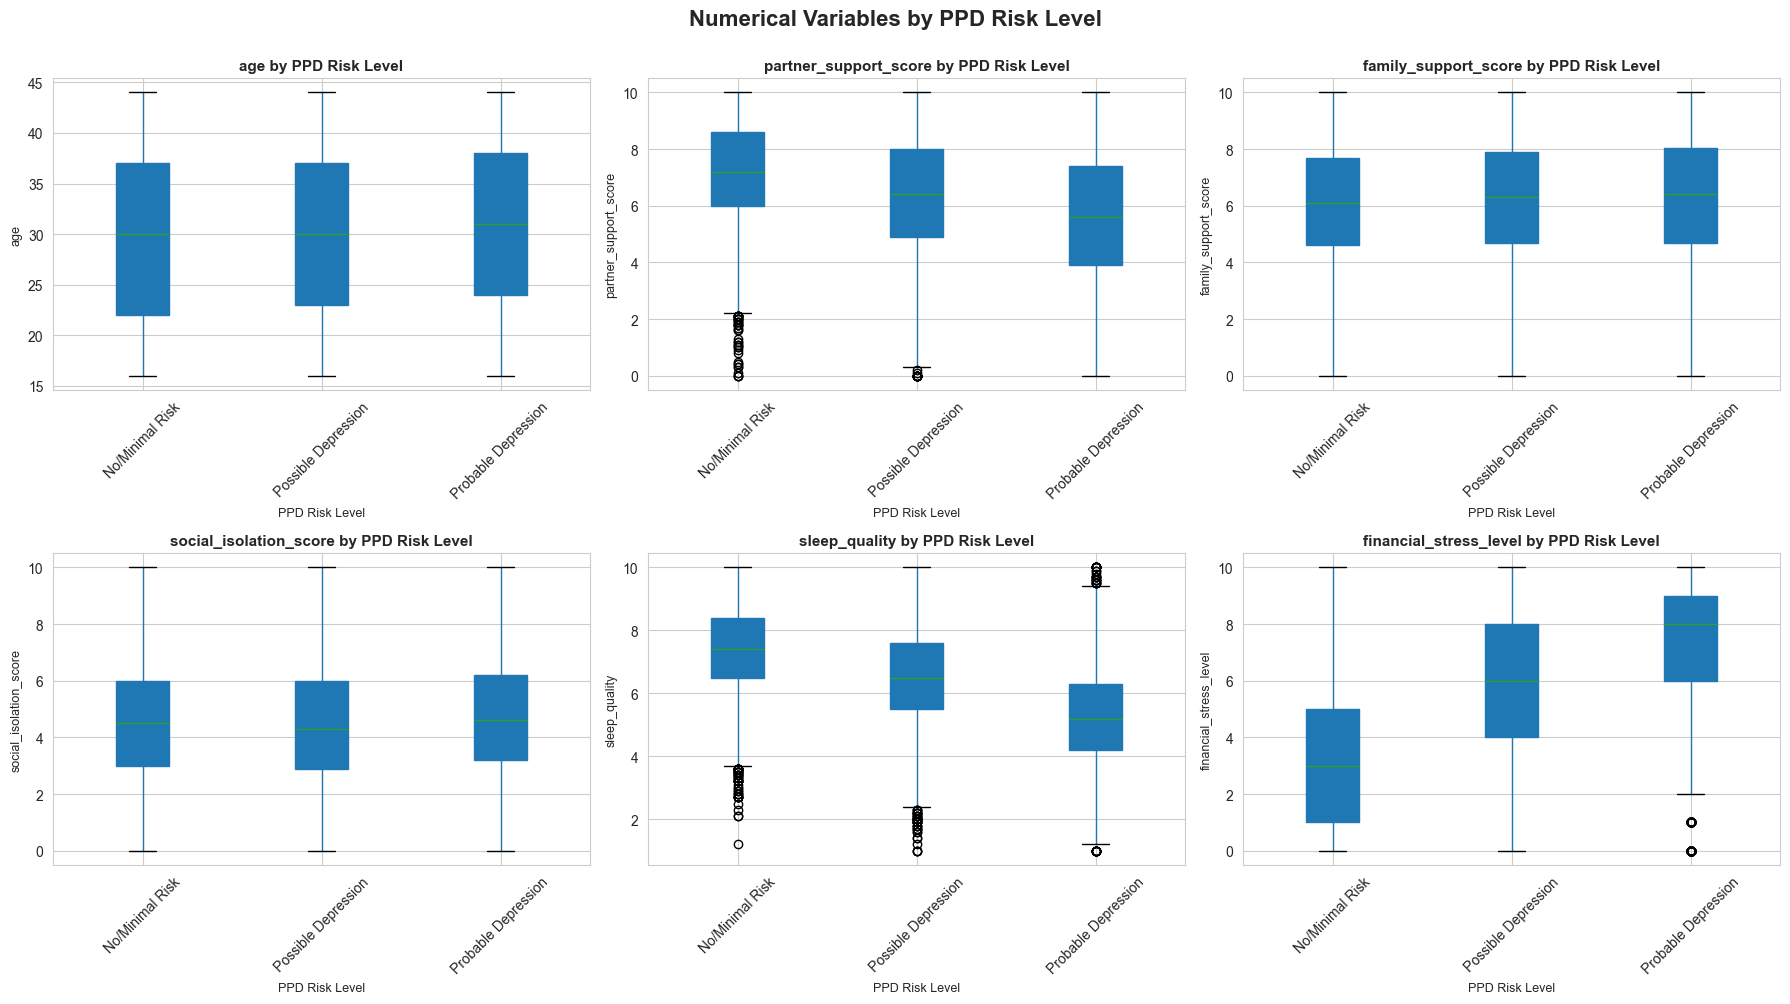

In [28]:
# Box plots: numerical variables by PPD risk level
numerical_cols = ['age', 'partner_support_score', 'family_support_score', 
                  'social_isolation_score', 'sleep_quality', 'financial_stress_level']

available_nums = [col for col in numerical_cols if col in df.columns]

if len(available_nums) > 0:
    n_rows = (len(available_nums) + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*5))
    axes = axes.flatten() if len(available_nums) > 1 else [axes]

    for idx, col in enumerate(available_nums):
        ax = axes[idx]
        df.boxplot(column=col, by='ppd_risk_level', ax=ax, patch_artist=True)
        ax.set_title(f'{col} by PPD Risk Level', fontsize=11, fontweight='bold')
        ax.set_xlabel('PPD Risk Level', fontsize=9)
        ax.set_ylabel(col, fontsize=9)
        plt.sca(ax)
        plt.xticks(rotation=45)

    # Hide extra subplots
    for idx in range(len(available_nums), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Numerical Variables by PPD Risk Level', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

**13. Data Validation Tests:**

In [29]:
# Data validation checks
print("=" * 20)
print("DATA VALIDATION TESTS:")
print("=" * 20)

validation_results = []

# 1. Age validation
age_valid = ((df['age'] >= 15) & (df['age'] <= 49)).all()
validation_results.append(("Age Range (15-49)", age_valid))

# 2. Support scores validation (0-10)
if 'partner_support_score' in df.columns:
    partner_valid = ((df['partner_support_score'] >= 0) & 
                     (df['partner_support_score'] <= 10)).all()
    validation_results.append(("Partner Support Score (0-10)", partner_valid))

if 'family_support_score' in df.columns:
    family_valid = ((df['family_support_score'] >= 0) & 
                    (df['family_support_score'] <= 10)).all()
    validation_results.append(("Family Support Score (0-10)", family_valid))

# 3. Sleep quality validation (0-10)
if 'sleep_quality' in df.columns:
    sleep_valid = ((df['sleep_quality'] >= 0) & (df['sleep_quality'] <= 10)).all()
    validation_results.append(("Sleep Quality (0-10)", sleep_valid))

# 4. Social isolation validation (0-10)
if 'social_isolation_score' in df.columns:
    isolation_valid = ((df['social_isolation_score'] >= 0) & 
                       (df['social_isolation_score'] <= 10)).all()
    validation_results.append(("Social Isolation Score (0-10)", isolation_valid))

# 5. Financial stress validation (0-10)
if 'financial_stress_level' in df.columns:
    financial_valid = ((df['financial_stress_level'] >= 0) & 
                       (df['financial_stress_level'] <= 10)).all()
    validation_results.append(("Financial Stress Level (0-10)", financial_valid))

# 6. Parity validation (non-negative)
if 'parity' in df.columns:
    parity_valid = (df['parity'] >= 0).all()
    validation_results.append(("Parity (>= 0)", parity_valid))

# 7. ANC visits validation (0-20)
if 'anc_visits' in df.columns:
    anc_valid = ((df['anc_visits'] >= 0) & (df['anc_visits'] <= 20)).all()
    validation_results.append(("ANC Visits (0-20)", anc_valid))

# 8. Gestational age validation (20-45 weeks)
if 'gestational_age' in df.columns:
    gest_valid = ((df['gestational_age'] >= 20) & (df['gestational_age'] <= 45)).all()
    validation_results.append(("Gestational Age (20-45 weeks)", gest_valid))

# 9. Monthly income validation (positive)
if 'monthly_household_income' in df.columns:
    income_valid = (df['monthly_household_income'] > 0).all()
    validation_results.append(("Monthly Household Income (> 0)", income_valid))

# Print results
for test, result in validation_results:
    status = "✓ PASS" if result else "✗ FAIL"
    print(f"{test:<45} {status}")

print("\n" + "=" * 60)
all_passed = all([result for _, result in validation_results])
if all_passed:
    print("✓ ALL VALIDATION TESTS PASSED")
else:
    print("✗ SOME VALIDATION TESTS FAILED - Review data generation logic")

DATA VALIDATION TESTS:
Age Range (15-49)                             ✓ PASS
Partner Support Score (0-10)                  ✓ PASS
Family Support Score (0-10)                   ✓ PASS
Sleep Quality (0-10)                          ✓ PASS
Social Isolation Score (0-10)                 ✓ PASS
Financial Stress Level (0-10)                 ✓ PASS
Parity (>= 0)                                 ✓ PASS
ANC Visits (0-20)                             ✓ PASS
Gestational Age (20-45 weeks)                 ✓ PASS
Monthly Household Income (> 0)                ✓ PASS

✓ ALL VALIDATION TESTS PASSED


**14. Data Quality Report Summary:**

In [30]:
# Comprehensive data quality report
print("=" * 27)
print("DATA QUALITY REPORT SUMMARY:")
print("=" * 27)

quality_metrics = {
    'Total Records': len(df),
    'Total Features': len(df.columns),
    'Numerical Features': len(df.select_dtypes(include=[np.number]).columns),
    'Categorical Features': len(df.select_dtypes(include=['object']).columns),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum(),
    'Memory Usage (MB)': df.memory_usage(deep=True).sum() / (1024**2)
}

print("\nDataset Overview:")
print("-" * 60)
for key, value in quality_metrics.items():
    if isinstance(value, float):
        print(f"{key:<30} {value:.2f}")
    else:
        print(f"{key:<30} {value}")

print("\n" + "=" * 60)
print("Data Quality Score:")
print("-" * 60)

# Calculate quality score
completeness = (1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100
uniqueness = (1 - df.duplicated().sum() / len(df)) * 100
overall_quality = (completeness + uniqueness) / 2

print(f"Completeness Score:  {completeness:.2f}%")
print(f"Uniqueness Score:    {uniqueness:.2f}%")
print(f"Overall Quality:     {overall_quality:.2f}%")

if overall_quality >= 95:
    print("\n✓ EXCELLENT DATA QUALITY")
elif overall_quality >= 80:
    print("\n✓ GOOD DATA QUALITY")
else:
    print("\n⚠ DATA QUALITY NEEDS IMPROVEMENT")

DATA QUALITY REPORT SUMMARY:

Dataset Overview:
------------------------------------------------------------
Total Records                  20000
Total Features                 32
Numerical Features             14
Categorical Features           18
Missing Values                 0
Duplicate Rows                 0
Memory Usage (MB)              21.36

Data Quality Score:
------------------------------------------------------------
Completeness Score:  100.00%
Uniqueness Score:    100.00%
Overall Quality:     100.00%

✓ EXCELLENT DATA QUALITY
